<img src="https://raw.githubusercontent.com/egiuse25/APS/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Emilia Giusepponi


# Consigna

## TS0: Primeros pasos en la simulación

En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

la amplitud máxima de la senoidal (volts)

su valor medio (volts)

la frecuencia (Hz)

la fase (radianes)

la cantidad de muestras digitalizada por el ADC (# muestras)

la frecuencia de muestreo del ADC.

es decir que la función que uds armen debería admitir se llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarán todas las funciones de visualización estilo Matlab. Para usarlo:

import matplotlib.pyplot as plt
plt.plot(tt, xx)

## Entrega
Recuerden que solo tienen que entregar una URL a su notebook. Con esa URL ya tendré acceso a su repositorio y todo lo que usaron.

https://nbviewer.jupyter.org/github/marianux/PDS/blob/main/preparacion.ipynb


Bonus:

💎 Ser el primero en subir un enlace a tu notebook en esta tarea

Realizar los experimentos que se comentaron en clase. Siguiendo la notación de la función definida más arriba:

ff = 500 Hz

ff = 999 Hz

ff = 1001 Hz

ff = 2001 Hz

🤯 Implementar alguna otra señal propia de un generador de señales. 

Ayudas:

La función numpy.sin seguro te va a servir.

No hace falta usar ningún lazo de control for, while, etc.

Podés consultar en el chat cualquier duda o problema que vayas encontrando. Buena suerte!


# Desarrollo 
## Definición de función seno
Para empezar, se comienza definiendo la función seno dada por:
$$x(t) = DC + A \cdot \sin(2\pi \cdot f \cdot t + \phi)$$
Siendo en el código:

• Señal senoidal ($x(t)$) = `xx`.

• Desplazamiento en el eje Y (Valor medio) ($DC$) = `dc`.

• Amplitud ($A$) = `vmax`.

• Frecuencia angular ($2\pi \cdot f $) = `2 * np.pi * ff`.

• Fase ($\phi$) = `ph`.

In [3]:
import numpy as np

#DEFINICION DE FUNCION SENO
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs # Tiempo entre cada muestra
    tt = np.arange(0, nn) * ts # Eje de tiempo
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph) # xx es la señal final
    tt = tt.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    xx = xx.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    return tt, xx

Posteriormente, se definen los valores de los parámetros dentro de la función seno:

In [5]:
vmax=1 # Amplitud = 1
dc=0 # Valor medio
ff=1 # Frecuencia
ph=0 # Fase
nn=1000 # Cantidad de muestras
fs=1000 # Frecuencia de muestreo

tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

Código para poder graficar la función senoidal con frecuencia de 1 Hz: 

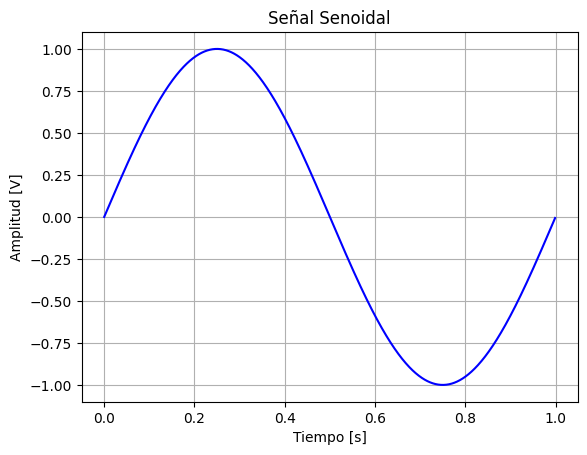

In [6]:
import matplotlib.pyplot as plt

plt.plot(tt, xx, color = 'blue') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal Senoidal")
plt.grid(True)
plt.show()



## Bonus: señal senoidal para distintas frecuencias

Según Nyquist, para que no haya solapamiento entre las réplicas de un espectro de frecuencias que se vuelve periódico, la frecuencia de la señal debe ser estrictamente menor a la mitad de la frecuencia de muestreo. A este límite se le llama frecuencia de Nyquist. 

Por lo que, para cualquier onda que, en este caso, tenga una frecuencia mayor de 500 Hz el sistema sufrirá un proceso irreversible de solapamiento espectral. Es decir, no será observada verdaderamente en los gráficos. Se observará una frecuencia aparente. En el caso de que la frecuencia sea igual a 500 Hz se observará un voltaje muy cercano a 0 debido a que ambas frecuencias aparentes se cancelarían mutuamente.


Dejando todos los valores fijos excepto el de la frecuencia, se observarán diferentes gráficos para cada una de ellas.


### Experimento 1: frecuencia de 500 Hz

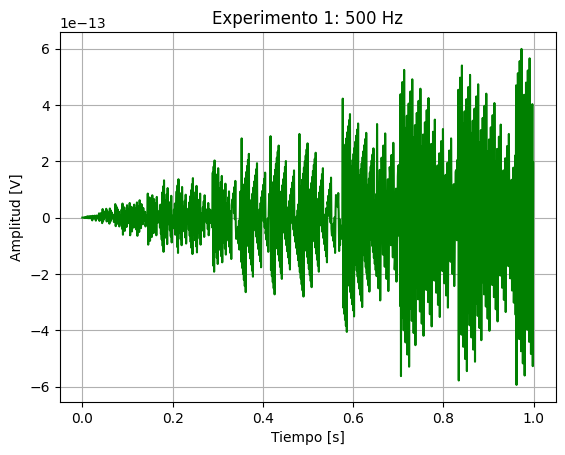

In [7]:
ff=500
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'green') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 1: 500 Hz")
plt.grid(True)
plt.show()



### Experimento 2: frecuencia de 999 Hz

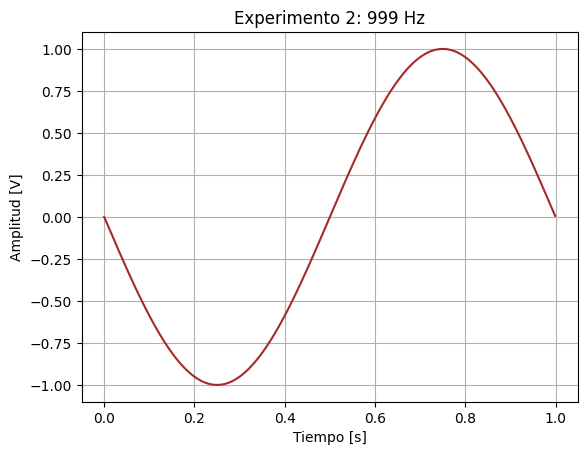

In [8]:
ff=999
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'brown') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 2: 999 Hz")
plt.grid(True)
plt.show()




### Experimento 3: frecuencia de 1001 Hz

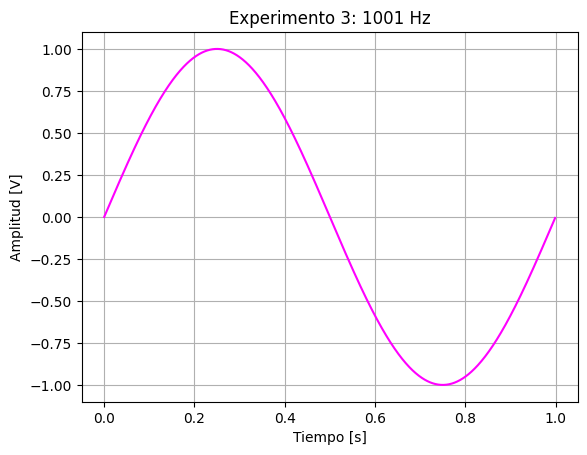

In [9]:
ff=1001
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'magenta') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 3: 1001 Hz")
plt.grid(True)
plt.show()



### Experimento 4: frecuencia de 2001 Hz

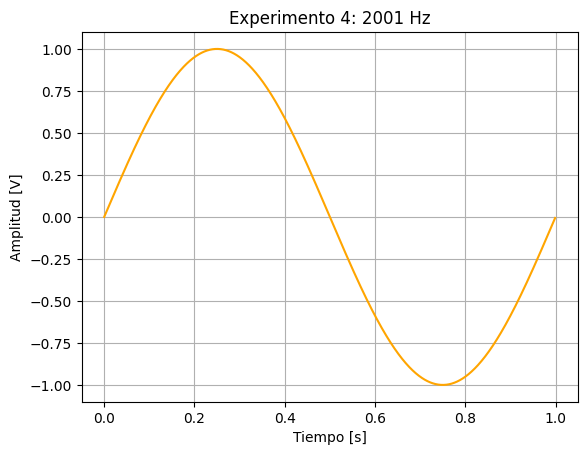

In [10]:
ff=2001
tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)
plt.plot(tt, xx, color = 'orange') 
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Experimento 4: 2001 Hz")
plt.grid(True)
plt.show()

## Muestreo de otro tipo de señal

Utilizando las librerías de SciPy, se pueden implementar [otro tipo de señales](https://docs.scipy.org/doc/scipy/reference/signal.html#waveforms), propias de un generador de señales. En este caso, la elegida fue la señal de onda cuadrada. 

Comenzamos nuevamente definiendo la función para la señal elegida y eligiendo los valores para cada variable dentro de ella. 

In [15]:
from scipy import signal # Agregamos libreria

def mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs # Tiempo entre cada muestra
    tt = np.arange(0, nn) * ts # Eje de tiempo
    xx = dc + vmax * signal.square(2 * np.pi * ff * tt + ph) 
    tt = tt.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    xx = xx.reshape(nn, 1) # Para asegurar que el tamaño sea de Nx1
    return tt, xx

vmax=1 # Amplitud = 1
dc=0 # Valor medio
ff=1 # Frecuencia
ph=0 # Fase
nn=1000 # Cantidad de muestras
fs=1000 # Frecuencia de muestreo


Posteriormente, el gráfico de la señal se vería así:

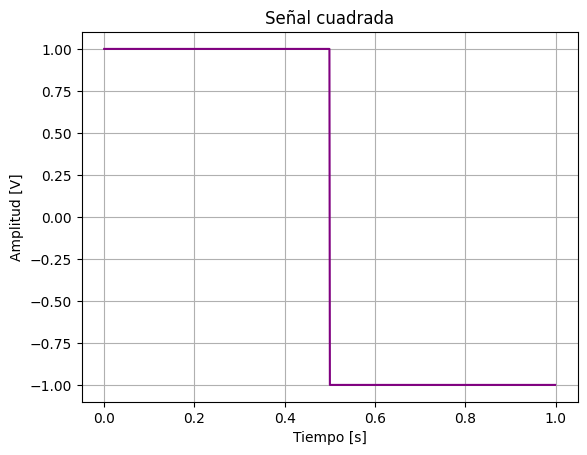

In [16]:
tt_cuadrada, xx_cuadrada = mi_funcion_cuadrada(vmax, dc, ff, ph, nn, fs)

plt.figure()
plt.plot(tt_cuadrada, xx_cuadrada, color='purple')
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuadrada")
plt.grid(True)
plt.show()
